# Problemas de Estadística Descriptiva

## Ejercicio 1 – ¿Qué tan largos son los títulos de las películas?

En este ejercicio vas a aplicar técnicas de estadística descriptiva sobre un conjunto de datos real: una base con 1000 películas populares del sitio IMDb.

A partir del título de cada película, vas a:
- Calcular la longitud del título (en caracteres).
- Obtener métricas estadísticas clave: media, mediana, moda, rango, varianza, desviación estándar, asimetría y curtosis.
- Identificar los títulos más largos y más cortos.
- Visualizar la distribución de estas longitudes con un histograma y una curva de densidad.


In [28]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, mode, gaussian_kde

# Cargar dataset de IMDb
url = "../assets/imdb_1000.csv"
df = pd.read_csv(url)
df



,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [29]:
# Crea una nueva columna llamada 'title_length' con la longitud (número de caracteres) de cada título
df['title_length'] = df['title'].astype(str).apply(len)
df

,star_rating,title,content_rating,genre,duration,actors_list,title_length
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt...",24
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']",13
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv...",22
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E...",15
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L....",12
...,...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G...",7
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma...",27
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo...",47
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr...",11


In [30]:
# Calcula media, mediana y moda de la columna 'title_length'
media = df['title_length'].mean()
mediana = df['title_length'].median()
moda = mode(df['title_length'], keepdims=True).mode[0]
print(f"Media: {media}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")

Media: 15.481103166496425
Mediana: 14.0
Moda: 12


In [31]:
# Calcula el rango, la varianza y la desviación estándar de 'title_length'
rango = df['title_length'].max() - df['title_length'].min()
varianza = df['title_length'].var()
desv_std = df['title_length'].std()
print(f"Rango: {rango}")
print(f"Varianza: {varianza}")
print(f"Desviación estándar: {desv_std}")

Rango: 67
Varianza: 72.1067488840288
Desviación estándar: 8.491569282766807


In [32]:
# Calcula asimetría y curtosis de la columna 'title_length'
asimetria = skew(df['title_length'])
curtosis_val = kurtosis(df['title_length'])
print(f"Asimetría: {asimetria}")
print(f"Curtosis: {curtosis_val}")


Asimetría: 1.5229143965677572
Curtosis: 3.7867237597626007


In [33]:
# Imprime el título más corto y el título más largo según su longitud
max_length = df['title_length'].max()
min_length = df['title_length'].min()

titulos_mas_largos = df[df['title_length'] == max_length]['title']
titulos_mas_cortos = df[df['title_length'] == min_length]['title']

print("\nTítulo mas largo:")
print(titulos_mas_largos.to_string(index=False))

print("\nTítulo mas corto:")
print(titulos_mas_cortos.to_string(index=False))


Título mas largo:
Dr. Strangelove or: How I Learned to Stop Worry...

Título mas corto:
M


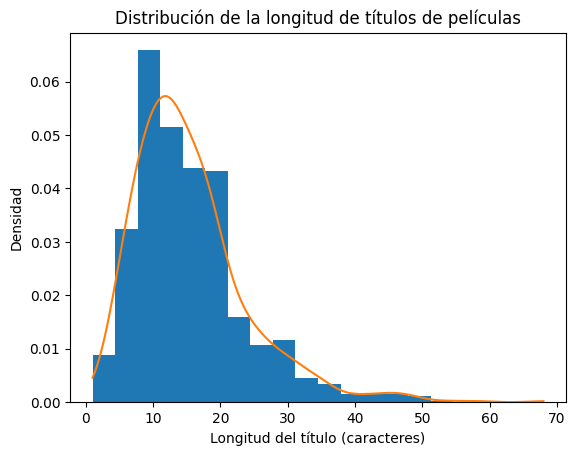

In [34]:
# grafica tus resultados
data = df['title_length']

plt.figure()
plt.hist(data, bins=20, density=True)
kde = gaussian_kde(data)
x_vals = np.linspace(data.min(), data.max(), 200)
plt.plot(x_vals, kde(x_vals))

plt.xlabel("Longitud del título (caracteres)")
plt.ylabel("Densidad")
plt.title("Distribución de la longitud de títulos de películas")

plt.show()

El histograma muestra que mayoría de los títulos están entre 10 y 20 caracteres y la curva de densidad muestra un pico principal alrededor de 12–15 caracteres, una cola larga hacia la derecha: hay unos títulos muy largos y no hay muchos titulos muy cortos, lo que produce una asimetría positiva.

---

## Ejercicio 2 – Cálculo manual de desviación estándar

En este ejercicio vas a calcular manualmente la desviación estándar, seleccionando cinco títulos reales del dataset de películas que cargaste antes.


In [35]:
# Crea una lista con 5 valores reales de df['title_length'], por ejemplo: [10, 13, 14, 18, 22]
valores = df['title_length'].iloc[0:5].tolist()
print("Valores seleccionados:", valores)

Valores seleccionados: [24, 13, 22, 15, 12]


In [36]:
# Calcula la media de los 5 valores
media = sum(valores) / len(valores)
print("Media:", media)

Media: 17.2


In [37]:
# Calcula las diferencias al cuadrado con respecto a la media
diferencias_cuadrado = [(x - media)**2 for x in valores]
print("Diferencias al cuadrado:", diferencias_cuadrado)

Diferencias al cuadrado: [46.24000000000001, 17.639999999999993, 23.040000000000006, 4.839999999999997, 27.039999999999992]


In [38]:
# Calcula la varianza (promedio de las diferencias al cuadrado) y su raíz cuadrada para obtener la desviación
varianza = sum(diferencias_cuadrado) / len(valores)
print("Varianza:", varianza)
desviacion = varianza ** 0.5
print("Desviación estándar:", desviacion)

Varianza: 23.76
Desviación estándar: 4.874423042781577
